In [1]:
import pdfplumber
import pandas as pd
import numpy as np
import os
import re
from tqdm import tqdm
import uuid
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns
from fastapi import FastAPI
import joblib
import shap


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


##EXTRACT TEXT FROM PDF


In [2]:
import fitz   # PyMuPDF
from tqdm import tqdm

In [3]:
pdf_folder = r"C:\Users\HP\OneDrive\Documents\axis_bank_recommendation\customer_statements"
output_folder = "output"

os.makedirs(output_folder, exist_ok=True)

##transaction categories

In [4]:
TRANSACTION_CATEGORIES = {
    # ==============================================
    # FOOD & DINING
    # ==============================================
    'FOOD_DELIVERY': [
        'ZOMATO', 'SWIGGY', 'EATSURE', 'UBER EATS', 'FOOD DELIVERY'
    ],
    'RESTAURANTS': [
        'ANNAPOORNA', 'KUPPANNA', 'SREE ANNAPOORNA', 'HOTEL ANNAPOORNA',
        'SHREE ANANDHAAS', 'KOVAI BIRIYANI', 'A2B', 'ADYAR ANANDA BHAVAN',
        'RESTAURANT', 'HOTEL', 'CAFE', 'BIRIYANI'
    ],
    'GROCERIES': [
        'DMART', 'SPAR', 'RELIANCE', 'RELIANCE FRESH', 'MORE SUPERMARKET',
        'NILGIRIS', 'PAZHAMUDIR', 'KOVAI PAZHAMUDIR', 'SUPERMARKET',
        'GROCERY', 'MORE'
    ],
    
    # ==============================================
    # SHOPPING
    # ==============================================
    'ONLINE_SHOPPING': [
        'AMAZON', 'FLIPKART', 'MYNTRA', 'AJIO', 'MEESHO', 'ONLINE SHOP'
    ],
    'FASHION': [
        'MAX', 'PANTALOONS', 'LIFESTYLE', 'ZARA', 'H&M', 'CLOTHING'
    ],
    'ELECTRONICS': [
        'RELIANCE DIGITAL', 'CROMA', 'POORVIKA', 'ELECTRONICS'
    ],
    
    # ==============================================
    # TRANSPORTATION
    # ==============================================
    'RIDE_HAILING': [
        'UBER', 'OLA', 'RAPIDO', 'CAB', 'TAXI'
    ],
    'FUEL': [
        'INDIAN OIL', 'HP PETROL', 'BHARAT PETROLEUM', 'BPCL', 'SHELL',
        'PETROL', 'FUEL', 'PETROL PUMP'
    ],
    'PUBLIC_TRANSPORT': [
        'BUS', 'TRAIN', 'METRO', 'IRCTC', 'RAILWAYS'
    ],
    
    # ==============================================
    # BILLS & UTILITIES
    # ==============================================
    'ELECTRICITY': [
        'TANGEDCO', 'ELECTRICITY', 'POWER', 'EB BILL'
    ],
    'INTERNET': [
        'ACT FIBERNET', 'ACTBB', 'JIO FIBER', 'AIRFIBER', 'BROADBAND',
        'INTERNET', 'WIFI'
    ],
    'MOBILE_RECHARGE': [
        'AIRTEL RECHARGE', 'JIO RECHARGE', 'VI RECHARGE', 'RECHARGE',
        'PREPAID', 'POSTPAID', 'MOBILE'
    ],
    'GAS': [
        'INDANE GAS', 'HP GAS', 'BHARAT GAS', 'LPG', 'GAS CYLINDER'
    ],
    'WATER': [
        'WATER', 'WATER BILL', 'METROWATER'
    ],
    
    # ==============================================
    # HEALTHCARE
    # ==============================================
    'PHARMACY': [
        'MEDPLUS', 'APOLLO PHARMACY', 'NETMEDS', 'PHARMACY', 'MEDICINE',
        'DRUGS', 'MEDSTORE'
    ],
    'HEALTHCARE': [
        'HOSPITAL', 'CLINIC', 'DOCTOR', 'HEALTH CHECKUP', 'MEDICAL'
    ],
    'HEALTH_INSURANCE': [
        'HEALTH INSURANCE', 'MEDICLAIM', 'INSURANCE PREMIUM'
    ],
    
    # ==============================================
    # ENTERTAINMENT & SUBSCRIPTIONS
    # ==============================================
    'STREAMING': [
        'NETFLIX', 'HOTSTAR', 'AMAZON PRIME', 'SONYLIV', 'ZEE5',
        'STREAMING', 'OTT'
    ],
    'ENTERTAINMENT': [
        'BOOKMYSHOW', 'PVR', 'INOX', 'CINEMA', 'MOVIE', 'THEATRE',
        'MULTIPLEX'
    ],
    'MUSIC': [
        'SPOTIFY', 'GAANA', 'WYNK', 'APPLE MUSIC', 'MUSIC'
    ],
    
    # ==============================================
    # FINANCIAL
    # ==============================================
    'INVESTMENTS': [
        'SIP', 'MUTUAL FUND', 'MF', 'AXISMUTUALFUND', 'ICICI MUTUAL',
        'HDFC MUTUAL', 'EQUITY', 'STOCKS', 'SHARES'
    ],
    'SALARY': [
        'SALARY', 'PSG INDUSTRIES', 'KOTAK BANK-SALARY', 'HDFC SALARY',
        'SALARY CREDIT', 'WAGE', 'PAYROLL'
    ],
    'BONUS': [
        'BONUS', 'INCENTIVE', 'PERFORMANCE BONUS'
    ],
    'INTEREST': [
        'INT/CREDIT', 'INTEREST', 'INTEREST CREDITED', 'INT PAID'
    ],
    'CREDIT_CARD_PAYMENT': [
        'CREDIT CARD', 'CC PAYMENT', 'AXIS CREDIT CARD', 'CARD PAYMENT',
        'BILLPAY/CREDIT CARD'
    ],
    'LOAN_REPAYMENT': [
        'EMI', 'LOAN', 'HOME LOAN', 'PERSONAL LOAN', 'AUTO LOAN',
        'LOAN REPAYMENT', 'PRINCIPAL', 'INTEREST'
    ],
    'INSURANCE': [
        'INSURANCE', 'LIFE INSURANCE', 'PREMIUM', 'POLICY'
    ],
    
    # ==============================================
    # TRANSFERS & PAYMENTS
    # ==============================================
    'FAMILY_SUPPORT': [
        'FAMILY SUPPORT', 'TO FAMILY', 'FROM FAMILY', 'MONEY TRANSFER HOME'
    ],
    'RECEIVED_MONEY': [
        'RECEIVED FROM', 'UPI/.*?/RECEIVED', 'TRANSFER FROM', 'CREDIT FROM'
    ],
    'SENT_MONEY': [
        'SENT TO', 'TRANSFER TO', 'PAYMENT TO'
    ],
    'RENT': [
        'RENT', 'LANDLORD', 'HOUSE RENT', 'RENT PAYMENT'
    ],
    
    # ==============================================
    # BANKING
    # ==============================================
    'ATM_WITHDRAWAL': [
        'ATM', 'ATM WITHDRAWAL', 'CASH WDL', 'CASH WITHDRAWAL',
        'ATM/CASH WDL'
    ],
    'BANK_CHARGES': [
        'CHARGES', 'BANK CHARGES', 'SMS ALERT', 'SMS CHARGES',
        'MAINTENANCE FEE', 'SERVICE CHARGES', 'CHG/'
    ],
    'CASH_DEPOSIT': [
        'CASH DEPOSIT', 'CASH DEPOSITED', 'DEPOSIT'
    ],
    
    # ==============================================
    # EDUCATION
    # ==============================================
    'EDUCATION': [
        'TUITION', 'SCHOOL FEES', 'COLLEGE FEES', 'EDUCATION',
        'COACHING', 'COURSE FEE', 'EXAM FEE'
    ],
    
    # ==============================================
    # TRAVEL & TOURISM
    # ==============================================
    'TRAVEL': [
        'FLIGHT', 'AIR TICKET', 'HOTEL BOOKING', 'MAKEMYTRIP', 'YATRA',
        'GOIBIBO', 'HOTEL STAY', 'RESORT', 'TOUR'
    ],
    
    # ==============================================
    # CHARITY & DONATIONS
    # ==============================================
    'CHARITY': [
        'DONATION', 'CHARITY', 'NGO', 'TEMPLE DONATION', 'CHURCH DONATION'
    ]
    

}

##Categorization function

In [5]:
def categorize_transaction(description):

    description = description.upper()

    for category, keywords in TRANSACTION_CATEGORIES.items():
        for word in keywords:
            if word in description:
                return category

    return "OTHER"

##Extract text from PDF

##Extract transactions using Regex

##Convert to DataFrame

##Function to safely search text

In [6]:
def safe_search(pattern, text):

    match = re.search(pattern, text, re.IGNORECASE | re.DOTALL)

    if match:
        return match.group(1).strip()

    return None

##Parse Account Information

In [7]:
def parse_customer_info(text):

    return {

        "customer_id": safe_search(r"Customer ID:\s*(\w+)", text),

        "account_number": safe_search(r"Account Number:\s*(\d+)", text),

        "account_type": safe_search(r"Account Type:\s*(.*?)\s*IFSC", text),

        "branch_name": safe_search(r"Branch:\s*(.*?)\s*Statement Period", text),

        "ifsc_code": safe_search(r"IFSC Code:\s*(\w+)", text),

        "customer_category": "Regular",

        "account_open_date": None
    }

##Parse Account Summary

In [8]:
def parse_account_summary(text):

    start_date = safe_search(
        r"Statement Period:\s*(\d{2}-\w{3}-\d{4})", text
    )

    end_date = safe_search(
        r"to\s*(\d{2}-\w{3}-\d{4})", text
    )

    return {

        "opening_balance": safe_search(
            r"Opening\s*Balance.*?([\d,]+\.\d+)", text
        ),

        "total_credits": safe_search(
            r"Total\s*Credits.*?([\d,]+\.\d+)", text
        ),

        "total_debits": safe_search(
            r"Total\s*Debits.*?([\d,]+\.\d+)", text
        ),

        "closing_balance": safe_search(
            r"Closing\s*Balance.*?([\d,]+\.\d+)", text
        ),

        "statement_start_date": start_date,

        "statement_end_date": end_date
    }

In [9]:
def parse_transactions(text, account_id):

    pattern = re.compile(
        r"(\d{2}-\d{2}-\d{4})\s+(.+?)\s+(\w+\d+)\s+(DR|CR)\s+([\d,]+\.\d+)\s+([\d,]+\.\d+)"
    )

    rows = []

    for match in pattern.finditer(text):

        transaction_id = str(uuid.uuid4())

        date = match.group(1)
        description = match.group(2)
        txn_type = match.group(4)

        amount = float(match.group(5).replace(",",""))
        balance = float(match.group(6).replace(",",""))

        category = categorize_transaction(description)

        rows.append({

            "transaction_id": transaction_id,

            "account_id": account_id,

            "transaction_date": date,

            "transaction_description": description,

            "transaction_type": txn_type,

            "amount": amount,

            "balance_after_transaction": balance,

            "transaction_category": category
        })

    return rows

##Extract them while processing PDF

In [10]:
def extract_text_from_pdf(pdf_path):

    text = ""

    with fitz.open(pdf_path) as doc:

        for page in doc:
            text += page.get_text()

    return text

In [11]:
customers = []
accounts = []
transactions = []

pdf_files = [f for f in os.listdir(pdf_folder) if f.endswith(".pdf")]

for file in tqdm(pdf_files):

    path = os.path.join(pdf_folder, file)

    text = extract_text_from_pdf(path)

    # ---------- Customer ----------
    customer = parse_customer_info(text)

    customer_id = customer["customer_id"]

    customers.append(customer)

    # ---------- Account ----------
    account_summary = parse_account_summary(text)

    account_id = str(uuid.uuid4())

    account_summary["account_id"] = account_id
    account_summary["customer_id"] = customer_id

    accounts.append(account_summary)

    # ---------- Transactions ----------
    txn_rows = parse_transactions(text, account_id)

    transactions.extend(txn_rows)

100%|██████████| 1000/1000 [04:13<00:00,  3.94it/s]


##Create DataFrames


In [12]:
customers_df = pd.DataFrame(customers)

accounts_df = pd.DataFrame(accounts)

transactions_df = pd.DataFrame(transactions)

##Save CSV files

In [13]:
customers_df.to_csv(f"{output_folder}/customers.csv", index=False)

accounts_df.to_csv(f"{output_folder}/accounts.csv", index=False)

transactions_df.to_csv(f"{output_folder}/transactions.csv", index=False)

print("All tables created successfully")

All tables created successfully


In [14]:
customers_df.head() 

,customer_id,account_number,account_type,branch_name,ifsc_code,customer_category,account_open_date
0,CIF00000001,920000000001,Burgundy Savings,Coimbatore - Mettupalayam Road,UTIB0001385,Regular,None
1,CIF00000002,920000000002,Easy Access Savings,Coimbatore - Sungam,UTIB0001385,Regular,None
2,CIF00000003,920000000003,Easy Access Savings,Coimbatore - Trichy Road,UTIB0001385,Regular,None
3,CIF00000004,920000000004,Easy Access Savings,Coimbatore - Saravanampatti,UTIB0001385,Regular,None
4,CIF00000005,920000000005,Prime Savings,Coimbatore - Trichy Road,UTIB0001385,Regular,None


In [15]:
customers_df.tail()

,customer_id,account_number,account_type,branch_name,ifsc_code,customer_category,account_open_date
995,CIF00000996,920000000996,Easy Access Savings,Coimbatore - Thudiyalur,UTIB0001385,Regular,None
996,CIF00000997,920000000997,Easy Access Savings,Coimbatore - Sungam,UTIB0001385,Regular,None
997,CIF00000998,920000000998,Easy Access Savings,Coimbatore - Ukkadam,UTIB0001385,Regular,None
998,CIF00000999,920000000999,Easy Access Savings,Coimbatore - Peelamedu,UTIB0001385,Regular,None
999,CIF00001000,920000001000,Prime Savings,Coimbatore - Thudiyalur,UTIB0001385,Regular,None


In [16]:
customers_df.describe()

,customer_id,account_number,account_type,branch_name,ifsc_code,customer_category,account_open_date
count,996,1000,1000,1000,1000,1000,0
unique,996,1000,3,18,1,1,0
top,CIF00000001,920000000001,Burgundy Savings,Coimbatore - Vadavalli,UTIB0001385,Regular,NaN
freq,1,1,336,71,1000,1000,NaN


In [17]:
customers_df.isnull().sum()

customer_id             4
account_number          0
account_type            0
branch_name             0
ifsc_code               0
customer_category       0
account_open_date    1000
dtype: int64

In [18]:
##fill null values for customer_df

In [19]:
customers_df["customer_id"] = customers_df["customer_id"].fillna(
    "CIF" + customers_df["account_number"].astype(str).str[-8:]
)

In [20]:
customers_df.isnull().sum()

customer_id             0
account_number          0
account_type            0
branch_name             0
ifsc_code               0
customer_category       0
account_open_date    1000
dtype: int64

In [21]:
customers_df.duplicated().sum()

np.int64(0)

In [22]:
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        1000 non-null   str   
 1   account_number     1000 non-null   str   
 2   account_type       1000 non-null   str   
 3   branch_name        1000 non-null   str   
 4   ifsc_code          1000 non-null   str   
 5   customer_category  1000 non-null   str   
 6   account_open_date  0 non-null      object
dtypes: object(1), str(6)
memory usage: 54.8+ KB


In [23]:
customers_df["account_type"] = customers_df["account_type"].astype("category")
customers_df["branch_name"] = customers_df["branch_name"].astype("category")
customers_df["customer_category"] = customers_df["customer_category"].astype("category")

In [24]:
customers_df.dtypes

customer_id               str
account_number            str
account_type         category
branch_name          category
ifsc_code                 str
customer_category    category
account_open_date      object
dtype: object

In [25]:
accounts_df.head()

,opening_balance,total_credits,total_debits,closing_balance,statement_start_date,statement_end_date,account_id,customer_id
0,"218,183.00","4,541,729.76","4,732,053.13","27,859.63",01-Jan-2021,23-Jan-2026,ef3ab827-3efe-41ac-94ff-67315339fc2b,CIF00000001
1,"96,966.00","961,789.01","970,874.74","87,880.27",01-Jan-2021,23-Jan-2026,bd0c0c98-ad21-4ef5-849e-604539cd127c,CIF00000002
2,"55,253.00","1,953,447.39","1,978,346.61","30,353.78",01-Jan-2021,23-Jan-2026,44db374d-9fed-4008-9b3a-74798e0e9a1d,CIF00000003
3,"182,406.00","3,025,475.44","2,146,990.98","1,060,890.46",01-Jan-2021,23-Jan-2026,2eb55923-2a6b-4f6a-8554-724c73b42ec0,CIF00000004
4,"162,226.00","3,925,762.77","4,934,117.48","846,128.71",01-Jan-2021,23-Jan-2026,e209e5f6-797d-4de0-8116-495776ef1731,CIF00000005


In [26]:
accounts_df.isnull().sum()

opening_balance         0
total_credits           0
total_debits            0
closing_balance         0
statement_start_date    0
statement_end_date      0
account_id              0
customer_id             4
dtype: int64

In [27]:
accounts_df.duplicated().sum()

np.int64(0)

In [28]:
accounts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   opening_balance       1000 non-null   str  
 1   total_credits         1000 non-null   str  
 2   total_debits          1000 non-null   str  
 3   closing_balance       1000 non-null   str  
 4   statement_start_date  1000 non-null   str  
 5   statement_end_date    1000 non-null   str  
 6   account_id            1000 non-null   str  
 7   customer_id           996 non-null    str  
dtypes: str(8)
memory usage: 62.6 KB


In [29]:
balance_cols = [
    "opening_balance",
    "total_credits",
    "total_debits",
    "closing_balance"
]

for col in balance_cols:
    accounts_df[col] = (
        accounts_df[col]
        .str.replace(",", "")
        .astype(float)
    )

In [30]:
accounts_df["statement_end_date"] = pd.to_datetime(
    accounts_df["statement_end_date"],
    format="%d-%b-%Y"
)

In [31]:
accounts_df.dtypes

opening_balance                float64
total_credits                  float64
total_debits                   float64
closing_balance                float64
statement_start_date               str
statement_end_date      datetime64[us]
account_id                         str
customer_id                        str
dtype: object

In [32]:
accounts_df.describe()

,opening_balance,total_credits,total_debits,closing_balance,statement_end_date
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1000
mean,2.247362e+05,6.044653e+06,4.085903e+06,2.463776e+06,2026-01-23 00:00:00
min,2.043600e+04,3.737456e+05,3.190520e+05,2.714000e+01,2026-01-23 00:00:00
25%,1.027435e+05,2.775885e+06,2.163497e+06,5.511518e+05,2026-01-23 00:00:00
50%,1.759955e+05,4.667818e+06,3.614331e+06,1.416701e+06,2026-01-23 00:00:00
75%,2.946030e+05,7.832884e+06,5.340030e+06,3.152290e+06,2026-01-23 00:00:00
max,1.085913e+06,3.139716e+07,1.909144e+07,2.089333e+07,2026-01-23 00:00:00
std,1.750117e+05,4.772740e+06,2.621840e+06,2.891076e+06,NaN


In [33]:
transactions_df.head()

,transaction_id,account_id,transaction_date,transaction_description,transaction_type,amount,balance_after_transaction,transaction_category
0,836ef4d0-9e2b-4f13-ba7b-726615283802,ef3ab827-3efe-41ac-94ff-67315339fc2b,01-12-2022,UPI/973571737/LANDLORD RENT/landlord@okhdfc,DR,15139.0,203044.0,RENT
1,cc1227e5-76ac-4b37-8a87-5d117d88cb44,ef3ab827-3efe-41ac-94ff-67315339fc2b,01-12-2022,POS/988002/AMAZON INDIA/CARD **9369,DR,3603.0,199441.0,ONLINE_SHOPPING
2,07713c83-21a0-49b7-a8f8-b0334d7a784b,ef3ab827-3efe-41ac-94ff-67315339fc2b,01-12-2022,UPI/957858928/RAPIDO/rapido@ybl,DR,135.0,199306.0,RIDE_HAILING
3,97267255-8dc8-498d-a273-06ce8a14347c,ef3ab827-3efe-41ac-94ff-67315339fc2b,03-12-2022,POS/214232/FLIPKART INDIA/CARD **9768,DR,1998.0,197308.0,ONLINE_SHOPPING
4,f300aa9c-d6cf-4736-be11-36dfc7729f88,ef3ab827-3efe-41ac-94ff-67315339fc2b,04-12-2022,UPI/233699231/EATSURE/eatsure@hdfcbank,DR,374.0,196934.0,FOOD_DELIVERY


In [34]:
transactions_df.isnull().sum()

transaction_id               0
account_id                   0
transaction_date             0
transaction_description      0
transaction_type             0
amount                       0
balance_after_transaction    0
transaction_category         0
dtype: int64

In [35]:
transactions_df.duplicated().sum()

np.int64(0)

In [36]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1044393 entries, 0 to 1044392
Data columns (total 8 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   transaction_id             1044393 non-null  str    
 1   account_id                 1044393 non-null  str    
 2   transaction_date           1044393 non-null  str    
 3   transaction_description    1044393 non-null  str    
 4   transaction_type           1044393 non-null  str    
 5   amount                     1044393 non-null  float64
 6   balance_after_transaction  1044393 non-null  float64
 7   transaction_category       1044393 non-null  str    
dtypes: float64(2), str(6)
memory usage: 63.7 MB


In [37]:
transactions_df.describe()

,amount,balance_after_transaction
count,1.044393e+06,1.044393e+06
mean,8.292456e+03,1.625261e+06
std,3.541793e+04,2.073344e+06
min,1.770000e+01,2.000000e+00
25%,4.000000e+02,3.016984e+05
50%,9.970000e+02,8.369854e+05
75%,2.635000e+03,2.099075e+06
max,7.241518e+05,2.089434e+07


In [38]:
transactions_df.dtypes

transaction_id                   str
account_id                       str
transaction_date                 str
transaction_description          str
transaction_type                 str
amount                       float64
balance_after_transaction    float64
transaction_category             str
dtype: object

fix null values for customer_df


In [39]:
# Convert date
transactions_df["transaction_date"] = pd.to_datetime(
    transactions_df["transaction_date"],
    format="%d-%m-%Y"
)

# Find earliest transaction
account_open_dates = (
    transactions_df
    .groupby("account_id")["transaction_date"]
    .min()
    .reset_index()
)

account_open_dates.rename(
    columns={"transaction_date": "account_open_date"},
    inplace=True
)

# Merge with accounts
accounts_df = accounts_df.merge(
    account_open_dates,
    on="account_id",
    how="left"
)

# Remove old column
customers_df.drop(columns=["account_open_date"], inplace=True)

# Merge with customers
customers_df = customers_df.merge(
    accounts_df[["customer_id", "account_open_date"]],
    on="customer_id",
    how="left"
)

In [40]:
customers_df.isnull().sum()

customer_id          0
account_number       0
account_type         0
branch_name          0
ifsc_code            0
customer_category    0
account_open_date    4
dtype: int64

In [41]:
customers_df[customers_df["account_open_date"].isnull()]

,customer_id,account_number,account_type,branch_name,ifsc_code,customer_category,account_open_date
64,CIF00000065,920000000065,Easy Access Savings,Coimbatore - Avinashi Road,UTIB0001385,Regular,NaT
84,CIF00000085,920000000085,Easy Access Savings,Coimbatore - RS Puram,UTIB0001385,Regular,NaT
360,CIF00000361,920000000361,Easy Access Savings,Coimbatore - Thudiyalur,UTIB0001385,Regular,NaT
602,CIF00000603,920000000603,Prime Savings,Coimbatore - RS Puram,UTIB0001385,Regular,NaT


In [42]:
accounts_df.isnull().sum()

opening_balance         0
total_credits           0
total_debits            0
closing_balance         0
statement_start_date    0
statement_end_date      0
account_id              0
customer_id             4
account_open_date       0
dtype: int64

In [43]:
accounts_df[accounts_df["customer_id"].isnull()]

,opening_balance,total_credits,total_debits,closing_balance,statement_start_date,statement_end_date,account_id,customer_id,account_open_date
64,287181.0,2697648.61,2163370.50,821459.11,01-Jan-2021,2026-01-23,d117010e-26bd-4759-9c48-48a41fea996d,NaN,2025-03-01
84,105870.0,3719054.75,3451957.73,372967.02,01-Jan-2021,2026-01-23,f40b5ca2-c022-4d5e-9c55-04ce5513a0a4,NaN,2023-09-02
360,341990.0,9981571.59,4931426.28,5392135.31,01-Jan-2021,2026-01-23,17ee69b2-18a0-4a69-ac8f-d732d90ae26a,NaN,2022-07-01
602,84958.0,3576191.58,3604272.83,56876.75,01-Jan-2021,2026-01-23,0a6829c9-e158-42b9-8aa9-c85a01550d71,NaN,2023-02-02


In [44]:
customer_map = customers_df.set_index("customer_id")

In [45]:
accounts_df["customer_id"] = accounts_df["customer_id"].fillna(
    customers_df["customer_id"]
)

In [46]:
accounts_df.isnull().sum()

opening_balance         0
total_credits           0
total_debits            0
closing_balance         0
statement_start_date    0
statement_end_date      0
account_id              0
customer_id             0
account_open_date       0
dtype: int64

In [47]:
accounts_df["statement_start_date"] = pd.to_datetime(
    accounts_df["statement_start_date"],
    format="%d-%b-%Y"
)

In [48]:
customers_df = customers_df.merge(
    accounts_df[["customer_id", "statement_start_date"]],
    on="customer_id",
    how="left"
)

customers_df["account_open_date"] = customers_df["account_open_date"].fillna(
    customers_df["statement_start_date"]
)

customers_df.drop(columns=["statement_start_date"], inplace=True)

In [49]:
customers_df.isnull().sum()

customer_id          0
account_number       0
account_type         0
branch_name          0
ifsc_code            0
customer_category    0
account_open_date    0
dtype: int64

In [50]:
customers_df.duplicated().sum()

np.int64(0)

##IDENTIFY NUMERIC COLUMNS

In [51]:
accounts_df.select_dtypes(include=['float64','int64']).columns

Index(['opening_balance', 'total_credits', 'total_debits', 'closing_balance'], dtype='str')

In [52]:
transactions_df.select_dtypes(include=['float64','int64']).columns

Index(['amount', 'balance_after_transaction'], dtype='str')

##ACCOUNTS DATA

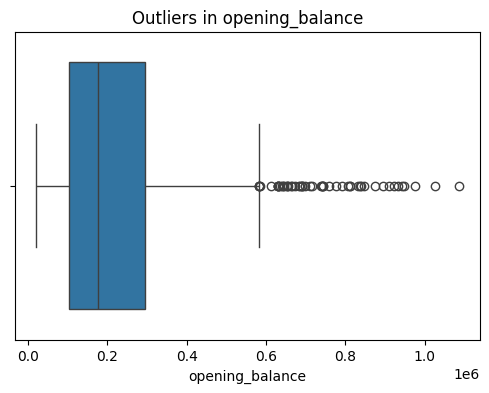

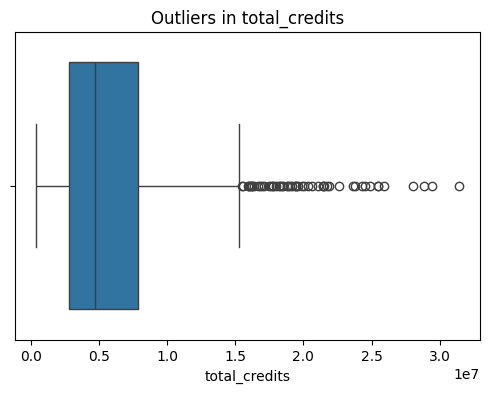

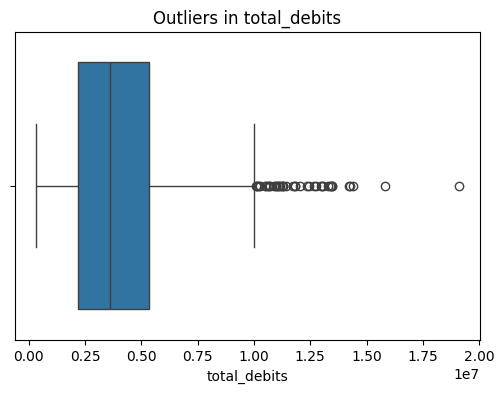

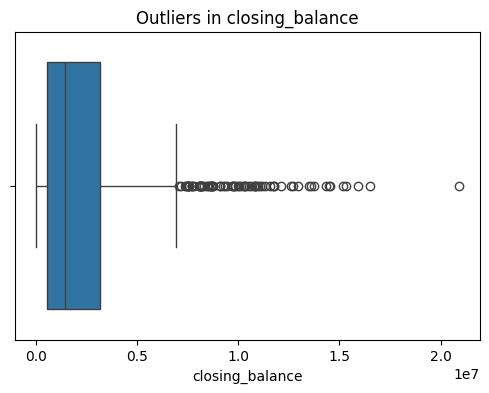

In [53]:
numeric_cols = ['opening_balance','total_credits','total_debits','closing_balance']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=accounts_df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

##Plot Each Column Separately

## Histogram + KDE

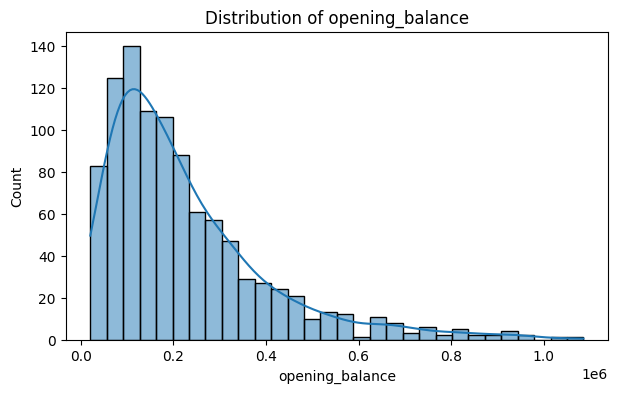

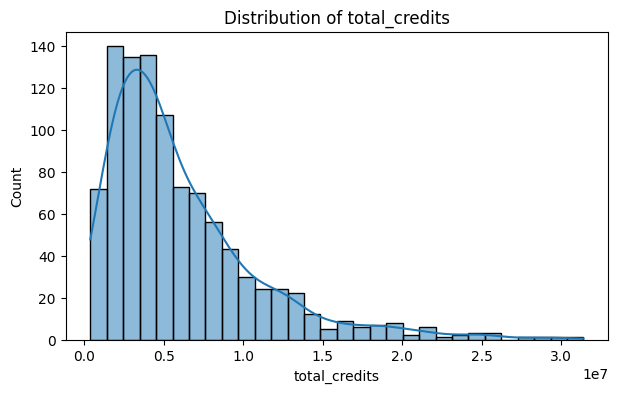

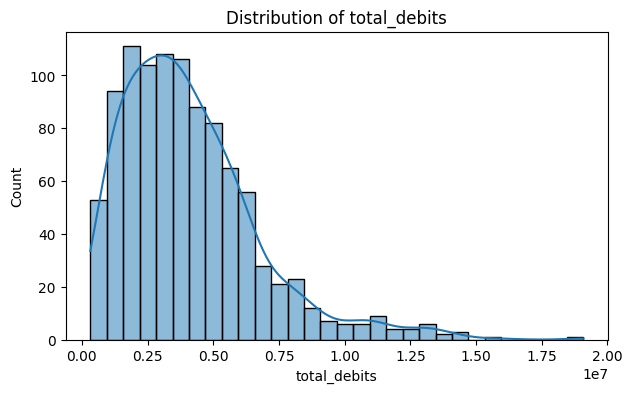

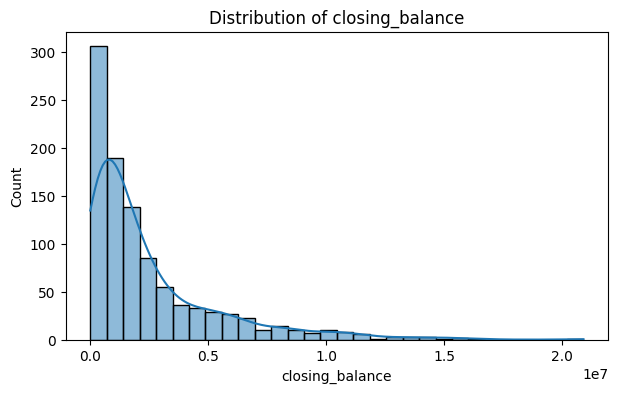

In [54]:
cols = [
    "opening_balance",
    "total_credits",
    "total_debits",
    "closing_balance"
]

for col in cols:
    
    plt.figure(figsize=(7,4))
    
    sns.histplot(accounts_df[col], bins=30, kde=True)
    
    plt.title(f"Distribution of {col}")
    
    plt.show()

In [55]:
def detect_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    return outliers

In [56]:
for col in ['opening_balance','total_credits','total_debits','closing_balance']:
    
    outliers = detect_outliers(accounts_df,col)
    
    print(f"{col} Outliers Count:",len(outliers))

opening_balance Outliers Count: 52
total_credits Outliers Count: 53
total_debits Outliers Count: 41
closing_balance Outliers Count: 80


## OUTLIER CAPPING FUNCTIONS

In [57]:
def cap_outliers_iqr(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower, upper)

    return df

In [58]:
cols = [
    "opening_balance",
    "total_credits",
    "total_debits",
    "closing_balance"
]

for col in cols:
    accounts_df = cap_outliers_iqr(accounts_df, col)

##verify outliers are removed

In [59]:
for col in cols:
    
    outliers = detect_outliers(accounts_df, col)
    
    print(col, "Outliers Count:", len(outliers))

opening_balance Outliers Count: 0
total_credits Outliers Count: 0
total_debits Outliers Count: 0
closing_balance Outliers Count: 0


##visual check

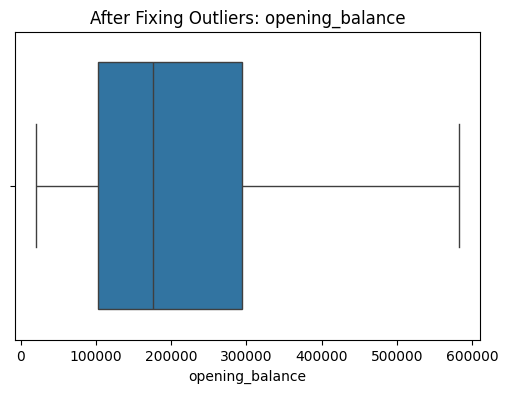

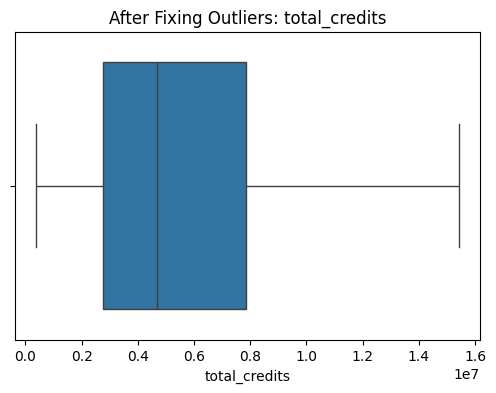

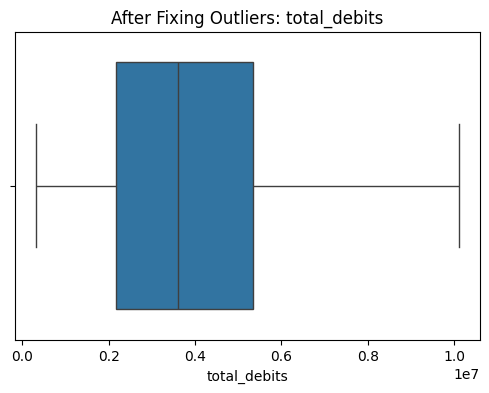

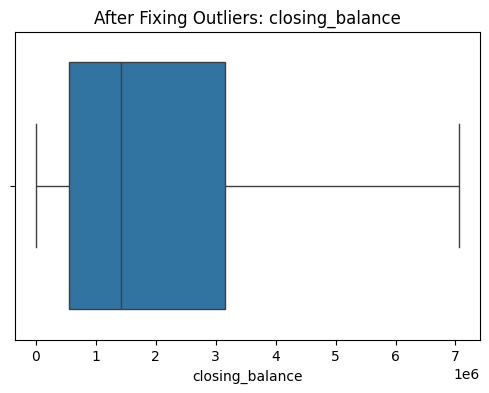

In [60]:
for col in cols:
    
    plt.figure(figsize=(6,4))
    sns.boxplot(x=accounts_df[col])
    plt.title(f"After Fixing Outliers: {col}")
    plt.show()

##check outliers in transactions

##visual check boxplot

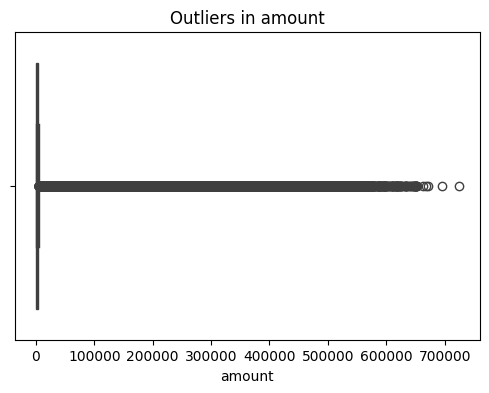

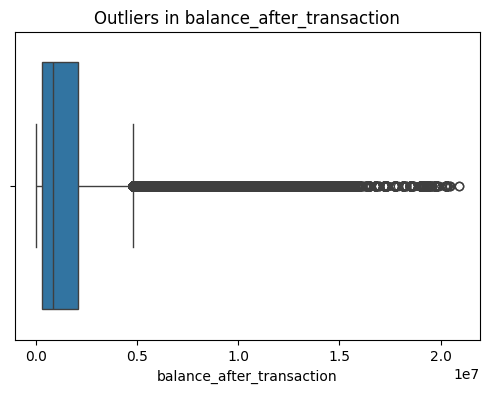

In [61]:
cols = ["amount", "balance_after_transaction"]

for col in cols:

    plt.figure(figsize=(6,4))
    sns.boxplot(x=transactions_df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

In [62]:
for col in ['amount','balance_after_transaction']:
    
    outliers = detect_outliers(transactions_df,col)
    
    print(f"{col} Outliers Count:",len(outliers))

amount Outliers Count: 131638
balance_after_transaction Outliers Count: 83384


In [63]:
def detect_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    return outliers

In [64]:
detect_outliers(transactions_df,"amount")

,transaction_id,account_id,transaction_date,transaction_description,transaction_type,amount,balance_after_transaction,transaction_category
0,836ef4d0-9e2b-4f13-ba7b-726615283802,ef3ab827-3efe-41ac-94ff-67315339fc2b,2022-12-01,UPI/973571737/LANDLORD RENT/landlord@okhdfc,DR,15139.00,203044.00,RENT
10,89894727-e135-446f-a320-cf53b7935467,ef3ab827-3efe-41ac-94ff-67315339fc2b,2022-12-09,SIP/AXISMUTUALFUND/SIP385145/MUTUAL FUND,DR,12443.55,180417.45,INVESTMENTS
14,71aac04a-8436-4b42-a358-e5d54950ab58,ef3ab827-3efe-41ac-94ff-67315339fc2b,2022-12-15,POS/210893/MEESHO INDIA/CARD **3036,DR,6514.00,170704.45,ONLINE_SHOPPING
26,97fd6a0b-aeb2-427f-ac41-f1775afe9eec,ef3ab827-3efe-41ac-94ff-67315339fc2b,2022-12-20,BILLPAY/AXIS CREDIT CARD/XXXX6977/PAYMENT,DR,23866.57,134051.88,CREDIT_CARD_PAYMENT
36,d2926b71-95a6-4e0a-9d32-fa69edec7ea1,ef3ab827-3efe-41ac-94ff-67315339fc2b,2022-12-29,NEFT-909816-KOTAK BANK-SALARY DEC,CR,99903.45,218182.33,SALARY
...,...,...,...,...,...,...,...,...
1044358,2a741d63-df0c-4bf0-8ca6-0ba9f0974478,c41ce930-3c61-47aa-ac13-c8603a81a2b7,2026-01-06,NEFT/459011/FAMILY SUPPORT/TRANSFER,DR,14288.00,8428341.24,FAMILY_SUPPORT
1044366,e7ac0d5d-bf3d-44fc-a6ff-9f808a794505,c41ce930-3c61-47aa-ac13-c8603a81a2b7,2026-01-11,NEFT/608301/HEALTH INSURANCE/PREMIUM,DR,23864.00,8398416.24,HEALTH_INSURANCE
1044385,fc399275-905d-497f-a201-db80e1324db1,c41ce930-3c61-47aa-ac13-c8603a81a2b7,2026-01-23,ATM/CASH WDL/S1SB8719/SBI ATM GANDHIPURAM,DR,10000.00,8368879.24,ATM_WITHDRAWAL
1044387,bf9000a3-3d1a-4854-b135-9eef16496b7b,c41ce930-3c61-47aa-ac13-c8603a81a2b7,2026-01-24,BILLPAY/AXIS CREDIT CARD/XXXX9841/PAYMENT,DR,17581.96,8351017.28,CREDIT_CARD_PAYMENT


In [65]:
customers_df

,customer_id,account_number,account_type,branch_name,ifsc_code,customer_category,account_open_date
0,CIF00000001,920000000001,Burgundy Savings,Coimbatore - Mettupalayam Road,UTIB0001385,Regular,2022-12-01
1,CIF00000002,920000000002,Easy Access Savings,Coimbatore - Sungam,UTIB0001385,Regular,2025-01-02
2,CIF00000003,920000000003,Easy Access Savings,Coimbatore - Trichy Road,UTIB0001385,Regular,2024-11-01
3,CIF00000004,920000000004,Easy Access Savings,Coimbatore - Saravanampatti,UTIB0001385,Regular,2023-09-01
4,CIF00000005,920000000005,Prime Savings,Coimbatore - Trichy Road,UTIB0001385,Regular,2022-09-01
...,...,...,...,...,...,...,...
995,CIF00000996,920000000996,Easy Access Savings,Coimbatore - Thudiyalur,UTIB0001385,Regular,2023-12-01
996,CIF00000997,920000000997,Easy Access Savings,Coimbatore - Sungam,UTIB0001385,Regular,2024-01-02
997,CIF00000998,920000000998,Easy Access Savings,Coimbatore - Ukkadam,UTIB0001385,Regular,2022-05-01
998,CIF00000999,920000000999,Easy Access Savings,Coimbatore - Peelamedu,UTIB0001385,Regular,2022-08-04


In [66]:
accounts_df

,opening_balance,total_credits,total_debits,closing_balance,statement_start_date,statement_end_date,account_id,customer_id,account_open_date
0,218183.0,4541729.76,4732053.13,2.785963e+04,2021-01-01,2026-01-23,ef3ab827-3efe-41ac-94ff-67315339fc2b,CIF00000001,2022-12-01
1,96966.0,961789.01,970874.74,8.788027e+04,2021-01-01,2026-01-23,bd0c0c98-ad21-4ef5-849e-604539cd127c,CIF00000002,2025-01-02
2,55253.0,1953447.39,1978346.61,3.035378e+04,2021-01-01,2026-01-23,44db374d-9fed-4008-9b3a-74798e0e9a1d,CIF00000003,2024-11-01
3,182406.0,3025475.44,2146990.98,1.060890e+06,2021-01-01,2026-01-23,2eb55923-2a6b-4f6a-8554-724c73b42ec0,CIF00000004,2023-09-01
4,162226.0,3925762.77,4934117.48,8.461287e+05,2021-01-01,2026-01-23,e209e5f6-797d-4de0-8116-495776ef1731,CIF00000005,2022-09-01
...,...,...,...,...,...,...,...,...,...
995,158605.0,3598227.56,3552385.99,2.044466e+05,2021-01-01,2026-01-23,e074e900-3bc7-4c8a-8b63-9df0e0f383f1,CIF00000996,2023-12-01
996,130305.0,3863064.84,2878630.68,1.114739e+06,2021-01-01,2026-01-23,d03dcece-c202-48be-bed2-81f312770555,CIF00000997,2024-01-02
997,93780.0,3604770.15,4204755.03,5.062049e+05,2021-01-01,2026-01-23,fd793c7c-bb05-4271-9eb3-46b0231fc8a8,CIF00000998,2022-05-01
998,44782.0,3550818.89,2706642.81,8.889581e+05,2021-01-01,2026-01-23,bcd23cbf-10e4-4a70-b3d0-d29c862cee18,CIF00000999,2022-08-04


In [67]:
transactions_df

,transaction_id,account_id,transaction_date,transaction_description,transaction_type,amount,balance_after_transaction,transaction_category
0,836ef4d0-9e2b-4f13-ba7b-726615283802,ef3ab827-3efe-41ac-94ff-67315339fc2b,2022-12-01,UPI/973571737/LANDLORD RENT/landlord@okhdfc,DR,15139.00,203044.00,RENT
1,cc1227e5-76ac-4b37-8a87-5d117d88cb44,ef3ab827-3efe-41ac-94ff-67315339fc2b,2022-12-01,POS/988002/AMAZON INDIA/CARD **9369,DR,3603.00,199441.00,ONLINE_SHOPPING
2,07713c83-21a0-49b7-a8f8-b0334d7a784b,ef3ab827-3efe-41ac-94ff-67315339fc2b,2022-12-01,UPI/957858928/RAPIDO/rapido@ybl,DR,135.00,199306.00,RIDE_HAILING
3,97267255-8dc8-498d-a273-06ce8a14347c,ef3ab827-3efe-41ac-94ff-67315339fc2b,2022-12-03,POS/214232/FLIPKART INDIA/CARD **9768,DR,1998.00,197308.00,ONLINE_SHOPPING
4,f300aa9c-d6cf-4736-be11-36dfc7729f88,ef3ab827-3efe-41ac-94ff-67315339fc2b,2022-12-04,UPI/233699231/EATSURE/eatsure@hdfcbank,DR,374.00,196934.00,FOOD_DELIVERY
...,...,...,...,...,...,...,...,...
1044388,7f1a5403-3748-4c8e-8996-28f719b32f62,c41ce930-3c61-47aa-ac13-c8603a81a2b7,2026-01-25,ATM/CASH WDL/S1AX2250/AXIS ATM SARAVANAMPATTI,DR,5000.00,8346017.28,ATM_WITHDRAWAL
1044389,3e3d1477-6481-4343-adc8-357dd99623ef,c41ce930-3c61-47aa-ac13-c8603a81a2b7,2026-01-25,UPI/102036539/OLA/ola@ybl,DR,87.00,8345930.28,RIDE_HAILING
1044390,df083a45-15a3-43eb-a89d-373374f439ef,c41ce930-3c61-47aa-ac13-c8603a81a2b7,2026-01-26,UPI/403767532/ZOMATO/zomato@hdfcbank,DR,492.00,8345438.28,FOOD_DELIVERY
1044391,f4b7f6ce-3bf6-4c4a-bb97-417806cddcec,c41ce930-3c61-47aa-ac13-c8603a81a2b7,2026-01-29,NEFT-205113-KMCH HOSPITAL-SALARY JAN,CR,319620.65,8665058.93,HEALTHCARE


##prepare data

In [68]:
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        1000 non-null   str           
 1   account_number     1000 non-null   str           
 2   account_type       1000 non-null   category      
 3   branch_name        1000 non-null   category      
 4   ifsc_code          1000 non-null   str           
 5   customer_category  1000 non-null   category      
 6   account_open_date  1000 non-null   datetime64[us]
dtypes: category(3), datetime64[us](1), str(3)
memory usage: 34.5 KB


In [69]:
accounts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   opening_balance       1000 non-null   float64       
 1   total_credits         1000 non-null   float64       
 2   total_debits          1000 non-null   float64       
 3   closing_balance       1000 non-null   float64       
 4   statement_start_date  1000 non-null   datetime64[us]
 5   statement_end_date    1000 non-null   datetime64[us]
 6   account_id            1000 non-null   str           
 7   customer_id           1000 non-null   str           
 8   account_open_date     1000 non-null   datetime64[us]
dtypes: datetime64[us](3), float64(4), str(2)
memory usage: 70.4 KB


In [70]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1044393 entries, 0 to 1044392
Data columns (total 8 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   transaction_id             1044393 non-null  str           
 1   account_id                 1044393 non-null  str           
 2   transaction_date           1044393 non-null  datetime64[us]
 3   transaction_description    1044393 non-null  str           
 4   transaction_type           1044393 non-null  str           
 5   amount                     1044393 non-null  float64       
 6   balance_after_transaction  1044393 non-null  float64       
 7   transaction_category       1044393 non-null  str           
dtypes: datetime64[us](1), float64(2), str(5)
memory usage: 63.7 MB


##Merge Account and Customer Info

In [71]:
txn = transactions_df.merge(
    accounts_df[["account_id", "customer_id"]],
    on="account_id",
    how="left"
)

txn["transaction_description"] = txn["transaction_description"].str.upper()

In [72]:
txn.head()

,transaction_id,account_id,transaction_date,transaction_description,transaction_type,amount,balance_after_transaction,transaction_category,customer_id
0,836ef4d0-9e2b-4f13-ba7b-726615283802,ef3ab827-3efe-41ac-94ff-67315339fc2b,2022-12-01,UPI/973571737/LANDLORD RENT/LANDLORD@OKHDFC,DR,15139.0,203044.0,RENT,CIF00000001
1,cc1227e5-76ac-4b37-8a87-5d117d88cb44,ef3ab827-3efe-41ac-94ff-67315339fc2b,2022-12-01,POS/988002/AMAZON INDIA/CARD **9369,DR,3603.0,199441.0,ONLINE_SHOPPING,CIF00000001
2,07713c83-21a0-49b7-a8f8-b0334d7a784b,ef3ab827-3efe-41ac-94ff-67315339fc2b,2022-12-01,UPI/957858928/RAPIDO/RAPIDO@YBL,DR,135.0,199306.0,RIDE_HAILING,CIF00000001
3,97267255-8dc8-498d-a273-06ce8a14347c,ef3ab827-3efe-41ac-94ff-67315339fc2b,2022-12-03,POS/214232/FLIPKART INDIA/CARD **9768,DR,1998.0,197308.0,ONLINE_SHOPPING,CIF00000001
4,f300aa9c-d6cf-4736-be11-36dfc7729f88,ef3ab827-3efe-41ac-94ff-67315339fc2b,2022-12-04,UPI/233699231/EATSURE/EATSURE@HDFCBANK,DR,374.0,196934.0,FOOD_DELIVERY,CIF00000001


##Calculate Months in Dataset

In [73]:
months = (
    (txn["transaction_date"].max() - txn["transaction_date"].min()).days
) / 30

months = round(months,2)

print("Months in dataset:", months)

Months in dataset: 61.9


##monthly spend

In [74]:
monthly_spend = (
    txn[txn["transaction_type"]=="DR"]
    .groupby("customer_id")["amount"]
    .sum()
) / months

In [75]:
monthly_spend.head()

customer_id
CIF00000001    53263.626817
CIF00000002    15684.567690
CIF00000003     6433.253635
CIF00000004    34684.830048
CIF00000005     6636.554120
Name: amount, dtype: float64

##monthly income

In [76]:
monthly_income = (
    txn[txn["transaction_type"]=="CR"]
    .groupby("customer_id")["amount"]
    .sum()
) / months

In [77]:
monthly_income.head()

customer_id
CIF00000001    73349.647173
CIF00000002    15537.786914
CIF00000003    29257.164136
CIF00000004    48876.824556
CIF00000005     4930.554927
Name: amount, dtype: float64

##debit card ratio 

In [78]:
debit = txn[txn["transaction_type"]=="DR"].groupby("customer_id")["amount"].sum()
credit = txn[txn["transaction_type"]=="CR"].groupby("customer_id")["amount"].sum()

debit_credit_ratio = debit / credit

In [79]:
debit_credit_ratio.head()

customer_id
CIF00000001    0.726161
CIF00000002    1.009447
CIF00000003    0.219886
CIF00000004    0.709638
CIF00000005    1.346006
Name: amount, dtype: float64

##emi spend ratio 

In [80]:
emi_keywords = ['EMI','LOAN','NACH','ECS']

txn["is_emi"] = txn["transaction_description"].str.contains(
    '|'.join(emi_keywords),
    case=False,
    na=False
)

emi_spend = txn[txn["is_emi"]].groupby("customer_id")["amount"].sum()

emi_spend_ratio = emi_spend / debit

In [81]:
emi_spend_ratio.head()

customer_id
CIF00000001    0.016575
CIF00000002    0.042962
CIF00000003    0.113064
CIF00000004    0.041623
CIF00000005         NaN
Name: amount, dtype: float64

##cash withdrawal ratio 

In [82]:
cash_keywords = ['ATM','CASH']

txn["is_cash"] = txn["transaction_description"].str.contains(
    '|'.join(cash_keywords),
    case=False,
    na=False
)

cash_spend = txn[txn["is_cash"]].groupby("customer_id")["amount"].sum()

cash_withdrawal_ratio = cash_spend / debit

In [83]:
cash_withdrawal_ratio.head()

customer_id
CIF00000001    0.121322
CIF00000002    0.193640
CIF00000003    0.067802
CIF00000004    0.228226
CIF00000005    0.131450
Name: amount, dtype: float64

##average monthly balance

In [84]:
avg_monthly_balance = txn.groupby("customer_id")["balance_after_transaction"].mean()
avg_monthly_balance.head()

customer_id
CIF00000001     53499.666093
CIF00000002     95606.623146
CIF00000003     28944.880870
CIF00000004    558979.482490
CIF00000005     70351.391737
Name: balance_after_transaction, dtype: float64

##Transaction Categorization

In [85]:
def categorize_transaction(description):

    for category, keywords in TRANSACTION_CATEGORIES.items():

        for keyword in keywords:

            if keyword in description:
                return category

    return "OTHER"

In [86]:
txn["transaction_category"] = txn["transaction_description"].apply(categorize_transaction)


##spending categories distribution

In [87]:
spending_distribution = pd.pivot_table(

    txn[txn["transaction_type"]=="DR"],
    values="amount",
    index="customer_id",
    columns="transaction_category",
    aggfunc="sum",
    fill_value=0

)

In [88]:
##convert to percentage
spending_distribution = spending_distribution.div(
    spending_distribution.sum(axis=1), axis=0
)

In [89]:
spending_distribution.head()

transaction_category,ATM_WITHDRAWAL,BANK_CHARGES,CASH_DEPOSIT,CREDIT_CARD_PAYMENT,ELECTRICITY,ENTERTAINMENT,FAMILY_SUPPORT,FOOD_DELIVERY,FUEL,GAS,...,INTERNET,INVESTMENTS,LOAN_REPAYMENT,MOBILE_RECHARGE,ONLINE_SHOPPING,PHARMACY,RENT,RESTAURANTS,RIDE_HAILING,STREAMING
customer_id,,,,,,,,,,,,,,,,,,,,,
CIF00000001,0.121322,0.000032,0.0,0.060632,0.016886,0.001366,0.060747,0.034795,0.029168,0.003742,...,0.006907,0.152944,0.000000,0.002663,0.184551,0.005598,0.191082,0.021890,0.008096,0.001315
CIF00000002,0.193640,0.000073,0.0,0.035001,0.026213,0.002195,0.106505,0.044724,0.038790,0.003034,...,0.008437,0.048665,0.000000,0.007145,0.271285,0.012260,0.000000,0.029909,0.014037,0.001233
CIF00000003,0.067802,0.000089,0.0,0.000000,0.004261,0.002092,0.059872,0.048295,0.005279,0.002373,...,0.005517,0.000000,0.113064,0.000000,0.188705,0.017920,0.327956,0.014522,0.012265,0.000500
CIF00000004,0.228226,0.000082,0.0,0.058779,0.014192,0.002267,0.068315,0.023086,0.055369,0.009750,...,0.007723,0.000000,0.000000,0.006391,0.069961,0.009294,0.296225,0.018000,0.017178,0.001045
CIF00000005,0.131450,0.000086,0.0,0.160733,0.016477,0.001217,0.032656,0.056820,0.000000,0.002670,...,0.008754,0.052592,0.000000,0.003522,0.250398,0.008625,0.167596,0.024562,0.007546,0.001212


##risk score

In [90]:
risk_score = (
    (debit_credit_ratio * 0.5) +
    (emi_spend_ratio * 0.3) +
    (cash_withdrawal_ratio * 0.2)
)

risk_score = risk_score * 100

In [91]:
risk_score.head()

customer_id
CIF00000001    39.231716
CIF00000002    55.634000
CIF00000003    15.742269
CIF00000004    41.295092
CIF00000005          NaN
Name: amount, dtype: float64

##create feature store table

In [92]:
features_df = pd.DataFrame({

"customer_id": monthly_spend.index,

"avg_monthly_balance": avg_monthly_balance.reindex(monthly_spend.index),

"monthly_spend": monthly_spend,

"debit_credit_ratio": debit_credit_ratio.reindex(monthly_spend.index),

"emi_spend_ratio": emi_spend_ratio.reindex(monthly_spend.index),

"cash_withdrawal_ratio": cash_withdrawal_ratio.reindex(monthly_spend.index),

"risk_score": risk_score.reindex(monthly_spend.index)

}).reset_index(drop=True)

In [93]:
features_df.head()

,customer_id,avg_monthly_balance,monthly_spend,debit_credit_ratio,emi_spend_ratio,cash_withdrawal_ratio,risk_score
0,CIF00000001,53499.666093,53263.626817,0.726161,0.016575,0.121322,39.231716
1,CIF00000002,95606.623146,15684.567690,1.009447,0.042962,0.193640,55.634000
2,CIF00000003,28944.880870,6433.253635,0.219886,0.113064,0.067802,15.742269
3,CIF00000004,558979.482490,34684.830048,0.709638,0.041623,0.228226,41.295092
4,CIF00000005,70351.391737,6636.554120,1.346006,NaN,0.131450,NaN


In [94]:
##add primary key 
features_df["feature_id"] = [
    str(uuid.uuid4()) for _ in range(len(features_df))
]

In [95]:
##add snapshot date
features_df["feature_snapshot_date"] = pd.Timestamp.today().date()

In [96]:
##merge spending distribution
features_df = features_df.merge(
    spending_distribution,
    on="customer_id",
    how="left"
)

##final feature store table

In [97]:
features_df.head()

,customer_id,avg_monthly_balance,monthly_spend,debit_credit_ratio,emi_spend_ratio,cash_withdrawal_ratio,risk_score,feature_id,feature_snapshot_date,ATM_WITHDRAWAL,...,INTERNET,INVESTMENTS,LOAN_REPAYMENT,MOBILE_RECHARGE,ONLINE_SHOPPING,PHARMACY,RENT,RESTAURANTS,RIDE_HAILING,STREAMING
0,CIF00000001,53499.666093,53263.626817,0.726161,0.016575,0.121322,39.231716,6c14b434-2fe6-4654-a90b-073872dd6c0d,2026-03-16,0.121322,...,0.006907,0.152944,0.000000,0.002663,0.184551,0.005598,0.191082,0.021890,0.008096,0.001315
1,CIF00000002,95606.623146,15684.567690,1.009447,0.042962,0.193640,55.634000,91137c59-a9ed-49a7-9683-455ad53e7514,2026-03-16,0.193640,...,0.008437,0.048665,0.000000,0.007145,0.271285,0.012260,0.000000,0.029909,0.014037,0.001233
2,CIF00000003,28944.880870,6433.253635,0.219886,0.113064,0.067802,15.742269,074f85f6-cc9b-4a09-b2a6-07abc2bd6cb4,2026-03-16,0.067802,...,0.005517,0.000000,0.113064,0.000000,0.188705,0.017920,0.327956,0.014522,0.012265,0.000500
3,CIF00000004,558979.482490,34684.830048,0.709638,0.041623,0.228226,41.295092,20ffa50a-4d64-44aa-bed0-d11c4d0f70c3,2026-03-16,0.228226,...,0.007723,0.000000,0.000000,0.006391,0.069961,0.009294,0.296225,0.018000,0.017178,0.001045
4,CIF00000005,70351.391737,6636.554120,1.346006,NaN,0.131450,NaN,518a9a2d-36ba-4315-8510-90cda3a5c73a,2026-03-16,0.131450,...,0.008754,0.052592,0.000000,0.003522,0.250398,0.008625,0.167596,0.024562,0.007546,0.001212


In [98]:
features_df.isnull().sum()

customer_id                0
avg_monthly_balance        0
monthly_spend              0
debit_credit_ratio        10
emi_spend_ratio          108
cash_withdrawal_ratio     11
risk_score               108
feature_id                 0
feature_snapshot_date      0
ATM_WITHDRAWAL             0
BANK_CHARGES               0
CASH_DEPOSIT               0
CREDIT_CARD_PAYMENT        0
ELECTRICITY                0
ENTERTAINMENT              0
FAMILY_SUPPORT             0
FOOD_DELIVERY              0
FUEL                       0
GAS                        0
GROCERIES                  0
HEALTH_INSURANCE           0
INTERNET                   0
INVESTMENTS                0
LOAN_REPAYMENT             0
MOBILE_RECHARGE            0
ONLINE_SHOPPING            0
PHARMACY                   0
RENT                       0
RESTAURANTS                0
RIDE_HAILING               0
STREAMING                  0
dtype: int64

In [99]:
features_df.duplicated().sum()

np.int64(0)

In [100]:
features_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            1000 non-null   str    
 1   avg_monthly_balance    1000 non-null   float64
 2   monthly_spend          1000 non-null   float64
 3   debit_credit_ratio     990 non-null    float64
 4   emi_spend_ratio        892 non-null    float64
 5   cash_withdrawal_ratio  989 non-null    float64
 6   risk_score             892 non-null    float64
 7   feature_id             1000 non-null   str    
 8   feature_snapshot_date  1000 non-null   object 
 9   ATM_WITHDRAWAL         1000 non-null   float64
 10  BANK_CHARGES           1000 non-null   float64
 11  CASH_DEPOSIT           1000 non-null   float64
 12  CREDIT_CARD_PAYMENT    1000 non-null   float64
 13  ELECTRICITY            1000 non-null   float64
 14  ENTERTAINMENT          1000 non-null   float64
 15  FAMILY_SUPPORT  

In [101]:
features_df.describe()

,avg_monthly_balance,monthly_spend,debit_credit_ratio,emi_spend_ratio,cash_withdrawal_ratio,risk_score,ATM_WITHDRAWAL,BANK_CHARGES,CASH_DEPOSIT,CREDIT_CARD_PAYMENT,...,INTERNET,INVESTMENTS,LOAN_REPAYMENT,MOBILE_RECHARGE,ONLINE_SHOPPING,PHARMACY,RENT,RESTAURANTS,RIDE_HAILING,STREAMING
count,1.000000e+03,1000.000000,990.000000,892.000000,989.000000,892.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.109755e+06,52158.544374,0.704973,0.121772,0.146379,40.495618,0.144768,0.000098,0.007356,0.089674,...,0.006913,0.078282,0.087101,0.004103,0.150267,0.007688,0.139861,0.019144,0.011161,0.000925
std,1.387667e+06,46073.799042,0.308511,0.107272,0.056892,12.845129,0.058604,0.000143,0.013484,0.054910,...,0.005234,0.076664,0.108513,0.002004,0.080860,0.004126,0.152215,0.008973,0.004708,0.000915
min,7.689097e+03,225.008078,0.123959,0.008738,0.013262,12.392228,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.053287e+05,16070.024596,0.509304,0.028385,0.105709,31.636243,0.104918,0.000038,0.000000,0.055624,...,0.004323,0.000000,0.000000,0.002868,0.091936,0.005088,0.000000,0.013617,0.008041,0.000498
50%,6.079297e+05,42993.258401,0.676835,0.085857,0.139016,40.218999,0.138655,0.000058,0.000000,0.083270,...,0.005908,0.079708,0.021875,0.004019,0.136602,0.007078,0.137096,0.018321,0.010539,0.000797
75%,1.502391e+06,75359.674838,0.824426,0.197216,0.180158,47.265013,0.180047,0.000099,0.010932,0.120069,...,0.007986,0.131283,0.161660,0.005349,0.197689,0.009521,0.265599,0.023612,0.013556,0.001171
max,9.470490e+06,308423.888368,3.661310,0.507122,0.409324,132.370098,0.409324,0.002146,0.096457,0.345693,...,0.063973,0.443285,0.488881,0.015115,0.734824,0.038114,0.722968,0.129312,0.044849,0.012433


In [102]:
##filling missing values
features_df.fillna(0, inplace=True)
features_df.isnull().sum()

customer_id              0
avg_monthly_balance      0
monthly_spend            0
debit_credit_ratio       0
emi_spend_ratio          0
cash_withdrawal_ratio    0
risk_score               0
feature_id               0
feature_snapshot_date    0
ATM_WITHDRAWAL           0
BANK_CHARGES             0
CASH_DEPOSIT             0
CREDIT_CARD_PAYMENT      0
ELECTRICITY              0
ENTERTAINMENT            0
FAMILY_SUPPORT           0
FOOD_DELIVERY            0
FUEL                     0
GAS                      0
GROCERIES                0
HEALTH_INSURANCE         0
INTERNET                 0
INVESTMENTS              0
LOAN_REPAYMENT           0
MOBILE_RECHARGE          0
ONLINE_SHOPPING          0
PHARMACY                 0
RENT                     0
RESTAURANTS              0
RIDE_HAILING             0
STREAMING                0
dtype: int64

In [103]:
features_df["feature_snapshot_date"] = pd.to_datetime(
    features_df["feature_snapshot_date"]
)

In [104]:
features_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype        
---  ------                 --------------  -----        
 0   customer_id            1000 non-null   str          
 1   avg_monthly_balance    1000 non-null   float64      
 2   monthly_spend          1000 non-null   float64      
 3   debit_credit_ratio     1000 non-null   float64      
 4   emi_spend_ratio        1000 non-null   float64      
 5   cash_withdrawal_ratio  1000 non-null   float64      
 6   risk_score             1000 non-null   float64      
 7   feature_id             1000 non-null   str          
 8   feature_snapshot_date  1000 non-null   datetime64[s]
 9   ATM_WITHDRAWAL         1000 non-null   float64      
 10  BANK_CHARGES           1000 non-null   float64      
 11  CASH_DEPOSIT           1000 non-null   float64      
 12  CREDIT_CARD_PAYMENT    1000 non-null   float64      
 13  ELECTRICITY            1000 no

## product catlog table

In [105]:
product_catalog = pd.DataFrame({

"product_id":[1,2,3,4,5],

"product_name":[

"Axis Credit Card",
"Personal Loan",
"Home Loan",
"Investment Plan",
"Premium Savings Account"

],

"product_type":[

"Credit Card",
"Loan",
"Loan",
"Investment",
"Account"

],

"eligibility_criteria":[

"High spend",
"Stable income",
"High income",
"High balance",
"High balance"

],

"risk_level":[

"Medium",
"Medium",
"Low",
"Low",
"Low"

]

})

In [117]:
product_catalog

,product_id,product_name,product_type,eligibility_criteria,risk_level
0,1,Axis Credit Card,Credit Card,High spend,Medium
1,2,Personal Loan,Loan,Stable income,Medium
2,3,Home Loan,Loan,High income,Low
3,4,Investment Plan,Investment,High balance,Low
4,5,Premium Savings Account,Account,High balance,Low


## Customer Segmentation (KMeans)

In [106]:
seg_features = features_df[[

"avg_monthly_balance",
"monthly_spend",
"risk_score"

]]

scaler = StandardScaler()

scaled = scaler.fit_transform(seg_features)

kmeans = KMeans(n_clusters=3, random_state=42)

features_df["customer_segment"] = kmeans.fit_predict(scaled)

In [ ]:


def assign_product(row):

    if row["avg_monthly_balance"] > 500000:
        return np.random.choice([4,3], p=[0.7,0.3])

    elif row["monthly_spend"] > 80000:
        return np.random.choice([1,2], p=[0.7,0.3])

    elif row["risk_score"] < 40:
        return np.random.choice([3,2], p=[0.7,0.3])

    else:
        return np.random.choice([2,1], p=[0.8,0.2])

In [110]:
features_df["product_id"] = features_df.apply(assign_product, axis=1)

In [119]:
feature_columns = [
"avg_monthly_balance",
"monthly_spend",
"debit_credit_ratio",
"emi_spend_ratio",
"cash_withdrawal_ratio",
"risk_score"
]

In [111]:
X = features_df[feature_columns]
y = features_df["product_id"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = RandomForestClassifier(n_estimators=200,random_state=42)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

Accuracy: 0.69
              precision    recall  f1-score   support

           1       0.80      0.36      0.50        11
           2       0.80      0.75      0.77        52
           3       0.57      0.46      0.51        61
           4       0.69      0.88      0.77        76

    accuracy                           0.69       200
   macro avg       0.71      0.61      0.64       200
weighted avg       0.69      0.69      0.68       200



In [115]:
importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

print(importance)

                 Feature  Importance
0    avg_monthly_balance    0.309541
5             risk_score    0.167315
2     debit_credit_ratio    0.160334
1          monthly_spend    0.157909
4  cash_withdrawal_ratio    0.103861
3        emi_spend_ratio    0.101039


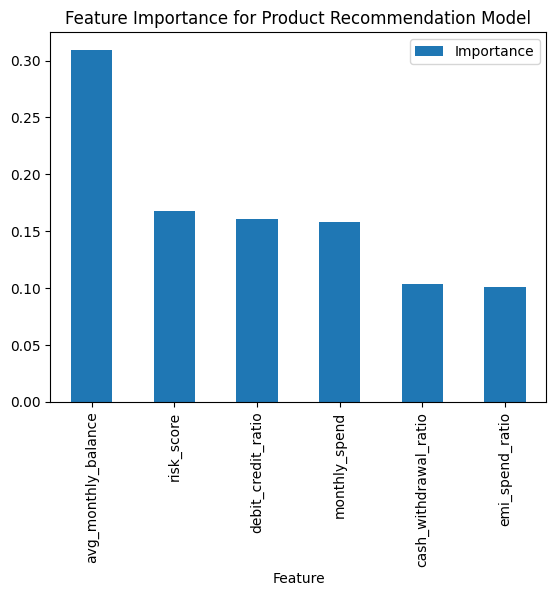

In [116]:

importance.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Feature Importance for Product Recommendation Model")
plt.show()

In [120]:
##recommendations table 


features_df["predicted_product"] = model.predict(X)

features_df["recommendation_score"] = model.predict_proba(X).max(axis=1)

recommendations_df = pd.DataFrame({

"recommendation_id":[str(uuid.uuid4()) for _ in range(len(features_df))],

"customer_id":features_df["customer_id"],

"product_id":features_df["predicted_product"],

"recommendation_score":features_df["recommendation_score"],

"recommendation_rank":1,

"recommendation_date":datetime.now(),

"recommendation_reason":"ML model based behavioral recommendation"

})

recommendations_df.head()

,recommendation_id,customer_id,product_id,recommendation_score,recommendation_rank,recommendation_date,recommendation_reason
0,eda749e7-b2c8-467a-94f7-f7ed1ed11f5e,CIF00000001,2,0.765,1,2026-03-16 22:35:51.057031,ML model based behavioral recommendation
1,1af951b7-aa8e-4969-a62b-ca9b3879058d,CIF00000002,2,0.925,1,2026-03-16 22:35:51.057031,ML model based behavioral recommendation
2,e5f9d222-161a-4eda-9b6a-0def5d1010d2,CIF00000003,3,0.900,1,2026-03-16 22:35:51.057031,ML model based behavioral recommendation
3,3b6f940e-7977-462e-9946-1c7a4d914cb8,CIF00000004,3,0.845,1,2026-03-16 22:35:51.057031,ML model based behavioral recommendation
4,74a5be79-26e0-4a17-951b-fb8b1f80d50a,CIF00000005,3,0.880,1,2026-03-16 22:35:51.057031,ML model based behavioral recommendation


In [121]:
def generate_reason(row):

    if row["avg_monthly_balance"] > 500000:
        return "High average balance detected – suitable for investment products"

    elif row["monthly_spend"] > 80000:
        return "High monthly spending pattern – credit card recommended"

    elif row["emi_spend_ratio"] > 0.3:
        return "Existing EMI commitments detected – loan restructuring or financial products recommended"

    elif row["risk_score"] < 40:
        return "Low financial risk profile – eligible for home loan"

    elif row["cash_withdrawal_ratio"] > 0.3:
        return "Frequent cash withdrawals – recommended digital banking offers"

    else:
        return "Balanced financial profile – suitable for personal banking products"

In [122]:
## generate prediction 
features_df["predicted_product"] = model.predict(X)

features_df["recommendation_score"] = model.predict_proba(X).max(axis=1)

In [124]:
features_df.head()

,customer_id,avg_monthly_balance,monthly_spend,debit_credit_ratio,emi_spend_ratio,cash_withdrawal_ratio,risk_score,feature_id,feature_snapshot_date,ATM_WITHDRAWAL,...,PHARMACY,RENT,RESTAURANTS,RIDE_HAILING,STREAMING,customer_segment,product_id,predicted_product,recommendation_score,recommendation_reason
0,CIF00000001,53499.666093,53263.626817,0.726161,0.016575,0.121322,39.231716,6c14b434-2fe6-4654-a90b-073872dd6c0d,2026-03-16,0.121322,...,0.005598,0.191082,0.021890,0.008096,0.001315,1,2,2,0.765,Low financial risk profile – eligible for home...
1,CIF00000002,95606.623146,15684.567690,1.009447,0.042962,0.193640,55.634000,91137c59-a9ed-49a7-9683-455ad53e7514,2026-03-16,0.193640,...,0.012260,0.000000,0.029909,0.014037,0.001233,1,2,2,0.925,Balanced financial profile – suitable for pers...
2,CIF00000003,28944.880870,6433.253635,0.219886,0.113064,0.067802,15.742269,074f85f6-cc9b-4a09-b2a6-07abc2bd6cb4,2026-03-16,0.067802,...,0.017920,0.327956,0.014522,0.012265,0.000500,0,3,3,0.900,Low financial risk profile – eligible for home...
3,CIF00000004,558979.482490,34684.830048,0.709638,0.041623,0.228226,41.295092,20ffa50a-4d64-44aa-bed0-d11c4d0f70c3,2026-03-16,0.228226,...,0.009294,0.296225,0.018000,0.017178,0.001045,1,3,3,0.845,High average balance detected – suitable for i...
4,CIF00000005,70351.391737,6636.554120,1.346006,0.000000,0.131450,0.000000,518a9a2d-36ba-4315-8510-90cda3a5c73a,2026-03-16,0.131450,...,0.008625,0.167596,0.024562,0.007546,0.001212,0,3,3,0.880,Low financial risk profile – eligible for home...


In [123]:
features_df["recommendation_reason"] = features_df.apply(generate_reason, axis=1)

In [125]:
recommendations_df = pd.DataFrame({

"recommendation_id":[str(uuid.uuid4()) for _ in range(len(features_df))],

"customer_id":features_df["customer_id"],

"product_id":features_df["predicted_product"],

"recommendation_score":features_df["recommendation_score"],

"recommendation_rank":1,

"recommendation_date":datetime.now(),

"recommendation_reason":features_df["recommendation_reason"]

})

recommendations_df.head()

,recommendation_id,customer_id,product_id,recommendation_score,recommendation_rank,recommendation_date,recommendation_reason
0,63a0aca8-92fb-43e4-8da2-3244dac51aac,CIF00000001,2,0.765,1,2026-03-16 22:48:08.700900,Low financial risk profile – eligible for home...
1,770d789d-c067-46e0-95ca-df7795b5f6da,CIF00000002,2,0.925,1,2026-03-16 22:48:08.700900,Balanced financial profile – suitable for pers...
2,8908532a-ec32-4e42-9822-e128a62ca2cf,CIF00000003,3,0.900,1,2026-03-16 22:48:08.700900,Low financial risk profile – eligible for home...
3,e55850ea-2f92-4a99-bc5e-9aba01a46fbb,CIF00000004,3,0.845,1,2026-03-16 22:48:08.700900,High average balance detected – suitable for i...
4,67dd0752-dfee-4b2c-b1cf-4d6ab4533e50,CIF00000005,3,0.880,1,2026-03-16 22:48:08.700900,Low financial risk profile – eligible for home...


In [128]:
##model metta data table
model_metadata_df = pd.DataFrame({

"model_id":[str(uuid.uuid4())],

"model_name":["Axis_Bank_Product_Recommendation_Model"],

"model_version":["v1.0"],

"training_date":[datetime.now()],

"evaluation_metrics":[f"Accuracy:{accuracy_score(y_test,pred)}"],

"deployment_status":["Development"]

})

model_metadata_df

,model_id,model_name,model_version,training_date,evaluation_metrics,deployment_status
0,35931854-8860-4480-8bea-3deee1c5c601,Axis_Bank_Product_Recommendation_Model,v1.0,2026-03-16 23:00:18.807664,Accuracy:0.69,Development


In [129]:


folder_path = "data/sql_upload"

os.makedirs(folder_path, exist_ok=True)

print("Folder created successfully")

Folder created successfully


In [133]:
customers_df = pd.read_csv("data/sql_upload/customers.csv")

accounts_df = pd.read_csv("data/sql_upload/accounts.csv")

transactions_df = pd.read_csv("data/sql_upload/transactions.csv")

features_df = pd.read_csv("data/sql_upload/feature_store.csv")

product_catalog_df = pd.read_csv("data/sql_upload/product_catalog.csv")

recommendations_df = pd.read_csv("data/sql_upload/recommendations.csv")

model_metadata_df = pd.read_csv("data/sql_upload/model_metadata.csv")

In [135]:


os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/trained_model.pkl")

print("Model saved successfully")

Model saved successfully


In [136]:

print(os.listdir("models"))

['trained_model.pkl']
